# numpy
[一个10分钟的numpy入门教程](https://www.bilibili.com/video/BV1Wy4y1h7ii/?spm_id_from=333.999.0.0&vd_source=ebaea6abaac375aa6cc338484b27226d)



numba 是一个即时编译（JIT）库，能将 Python 函数（尤其是数值计算、循环密集型函数）直接编译成机器码，无需修改太多代码就能大幅提升运行速度，核心优势是CPU 端加速，对 NumPy 数组操作友好。
cupy 是基于 CUDA 的 GPU 加速库，API 几乎和 NumPy 完全一致，核心优势是GPU 端加速，适合大规模数组运算（需英伟达显卡 + CUDA 环境）。


下载常用的数据分析库：
```shell
pip install numpy
pip install pandas
pip install matplotlib
```

## 向量化

In [ ]:
# 对于任何想要运算的的数据，我们需要预先将它们表示成numpy数组的形式，这一操作我们称之为 【向量化（Vectorization）】
# numpy为我们提供了一个特殊的数组对象`numpy.array()`，我们可以用它表示普通的一维的数组、二维的矩阵、任意维的数据，并且对数组中的数据进行高效的运算

import numpy as np
# 创建数组对象 np.array
a = np.array([1, 2, 3, 4, 5]) # 一维数组
b = np.array([[1, 2, 3], [4, 5, 6]]) # 二维数组
c = np.array([[[1, 2, 3], [4, 5, 6]], [[7, 8, 9], [1, 2, 3]]]) # 三维数组
print(a)
print(b)
print(c)


# 创建全部为0的数组 np.zeros
print(np.zeros(3, dtype="int64"))  # 1维  3列
print(np.zeros((3, 2)))  # 2维  3行 2列
print(np.zeros(((3, 2, 5))))  # 3维 3层 2行 5列


# 创建全部为1的数组 np.ones
print(np.ones(3))  # 1维  3列
print(np.ones((3, 2)))  # 2维  3行 2列
print(np.ones(((3, 2, 5))))  # 3维 3层 2行 5列


# 生成随机的数组 np.random.rand()
np.random.rand(2, 4)  # 2行 4 列


# 创造一个递增/递减的数组  numpy.arange(start, stop, step, dtype = None)
a = np.arange(3, 7)  # 3-6
print(a)



# np. linspace()会返回介于某个区间，等间距分布的数
np.linspace(0, 1, 5)
# 前面两个参数是区间的参数，最后一个参数是输出的样本个数



# numpy也支持从外部读取数据来创建数组，例如从硬盘中读取csv、txt等文件来创建数组。
# np.genfromtxt()是numpy中读取文件的一个方法，例如在当前目录下有一个data.csv文件，从文件中读取数据并创建数组对象
np.genfromtxt('data.csv',delimiter=',',skip_header=1)

### 数组的数据类型


In [ ]:
# 获取数组的尺寸
a = np.zeros((3, 2))  # 3行 2列
print(a.shape)


# 在numpy中，数组默认的数据类型是float64
a = np.zeros((2, 4))
a.dtype

# 我们可以在创建数组时，通过dtype指定其他的数据类型
a = np.zeros((2, 4), dtype="int32")
a.dtype



# 对于现有的数组，我们也可以`astype(...)`来转换数据类型
a = np.arange(5, 10)
print(a.dtype)
b = a.astype("int32")
print(a.dtype)
print(b.dtype)


# 整形
np.int8
np.int16
np.int32
np.int64

# 无符号整型
np.uint8
np.uint16
np.uint32
np.uint64

# 浮点数
np.float32
np.float64

bool
str
...

## 基本运算
两个相同尺寸的数组可以直接进行四则运算，它会将数组同位置的元素进行加减乘除。

不同尺寸的数组也可以直接进行运算，在运算之前，numpy会将这两个数组扩展至相同的尺寸，然后再将相同位置的元素相加。
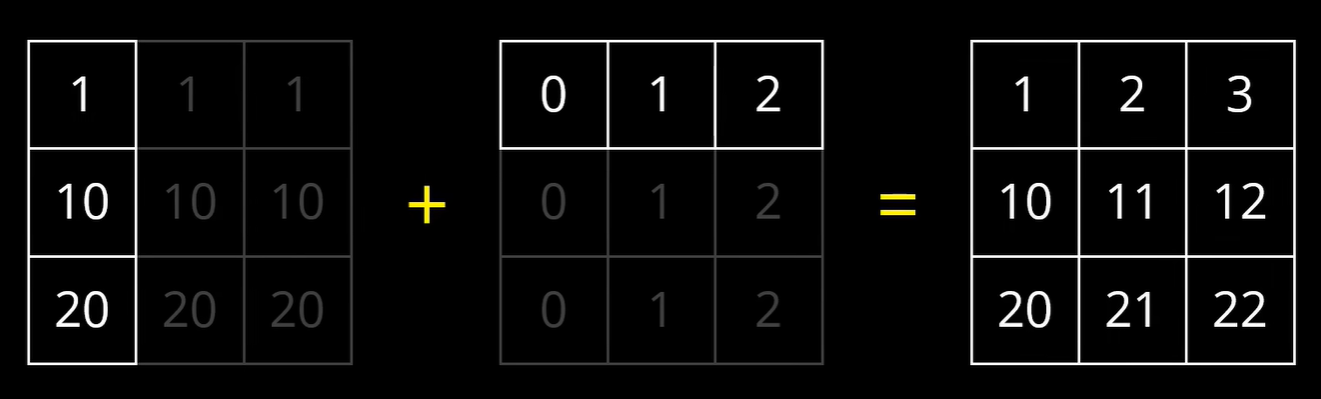


In [ ]:
a = np.array([1,2,3])
b = np.array([4,5,6])

print(a + b)
print(a - b)
print(a * b)
print(a / b)

### 点乘 np.dot

In [ ]:
a = np.array([1,2,3])
b = np.array([4,5,6])
np.dot(a,b)

### 叉乘 np.matmul

In [ ]:
a = np.array([
    [1,2],
    [3,4]
])
b = np.array([
    [2,0],
    [0,2]
])
print(np.matmul(a,b))

# 也可以使用如下写法
print(a @ b)

### 求平方根
对数组中的所有数依次求平方根

In [ ]:
a = np.array([1,2,3])
np.sqrt(a)

### 三角函数

In [ ]:
a = np.array([1,2,3])
print(np.sin(a))

print(np.cos(a))

### 指数、对数运算

In [ ]:
a = np.array([1,2,3])
print(np.log(a))

print(np.power(a,2))

### array * 单个数（广播 broadcasting）
numpy会分别计算各个元素与这个数的乘积，这个操作在numpy里面被称为广播。

In [ ]:
a = np.array([1,2,3])
print(a * 5)

### 最大、最小

In [ ]:
a = np.array([5,7,6,9])
print(np.max(a))
print(np.min(a))
print(np.argmax(a))
print(np.argmin(a))

### 总和、平均值、中位数....

In [ ]:
a = np.array([5,7,6,9,8,1,4])
print(np.sum(a)) # 总和
print(np.mean(a)) #平均值
print(np.median(a)) #中位数
print(np.var(a)) #方差
print(np.std(a)) #标准方差

对于以上提到的函数，如果操作对象是多维数组，你还可以指定一个额外的参数axis
当axis=0时，它会将每一行中对应的数据相加。
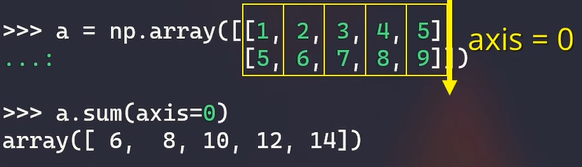

axis=0表示第一个维度，以此类推，axis=1代表第二个维度。

### 获取元素
如下

In [ ]:
b = np.array([1,2,3])
print(b[0])

a = np.array([
    [1,2,3],
    [4,5,6]
])
print(a[0,1])# 获取第一行，第二列的元素

#### 通过条件筛选元素

In [ ]:
a = np.array([
    [1,2,3],
    [4,5,6]
])
print(a[a > 3])

b = np.array([
    [1,5,6,8],
    [8,3,7,6]
])
print(b[(b > 5) & (b % 2 ==0)])

In [ ]:
a = np.array([
    [1,2,3],
    [4,5,6]
])
a[0,0:2]

#### 切片

In [ ]:
a = np.array([
    [1,2,3],
    [4,5,6]
])
print(a [0,0:2]) #获取 第一行 第0-1列的数据
print(a [0,0:3:2]) # 步长2，每隔两个数取一个数
print(a [0,:]) # 获取第一行 全部数据
print(a [0]) #或者直接这样写
print(a[::-1])

## 图片处理
通常我们可以把一张灰度图看作是1个二维的数组，数组中的每个元素用来表示像素点的亮度值
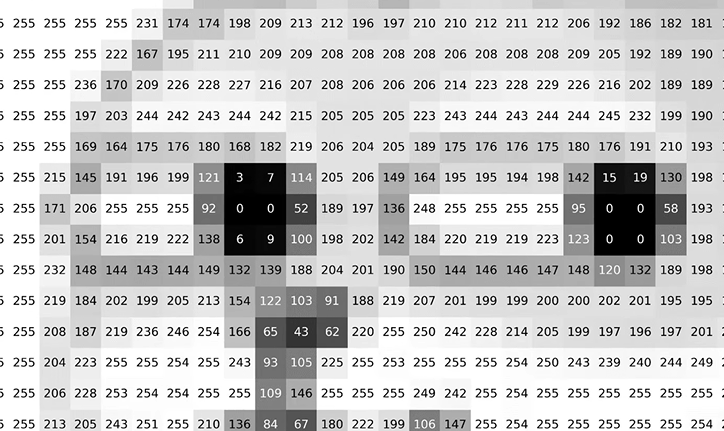

对于彩色的图片，我们可以用三维的数组来表示，数组中的第三维分别存储了像素点的红绿蓝分量
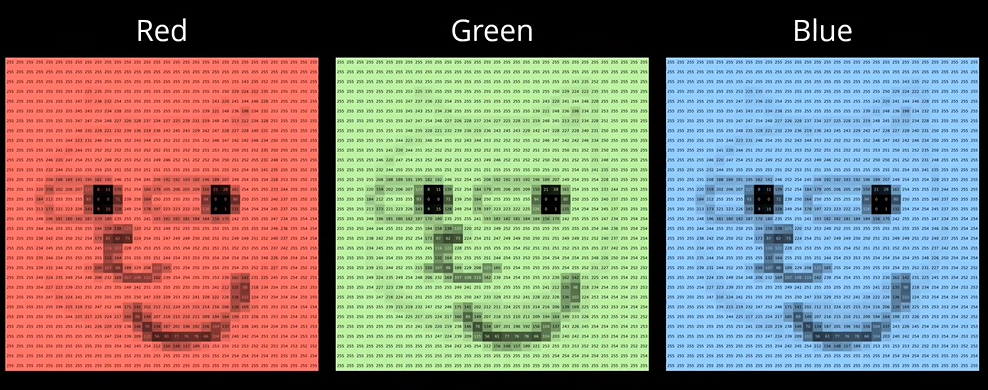

我们可以使用pillow这个库读取图片

In [ ]:
from PIL import Image
im = Image.open('doge.jpg')
im.show()

随后可以使用numpy来将图片转为数组

In [ ]:
im = np.array(im)
im.shape # 行 列 颜色分类（红、蓝、绿）

In [ ]:
# 通过下标来访问某个像素点的颜色
im[100,100]

In [ ]:
#单独提取出所有点的红色分量
im_r = im[:,:,0]
Image.fromarray(im_r).show()

### 将两个图片混合在一起

In [ ]:
im1 = np.array(Image.open("doge.jpg"))
im2 = np.array(Image.open("cat.jpg"))
im1 = im1[0:300, 0:300, :]
im2 = im2[0:300, 0:300, :]
im_blend = im1 * 0.4 + im2 * 0.6

# 这里需要注意的是运算的结果是浮点数，为了显示图片，我们需要将图片转换成整型数
im_blend = im_blend.astype(np.uint8)
Image.fromarray(im_blend).show()

### 降采样

In [ ]:
im_downsample = im[::10,::10,:]

### 翻转图片

In [ ]:
im = np.array(Image.open('doge.jpg'))
im_flipped = im[::-1,:,:]
Image.fromarray(im_flipped).show()

### 裁剪图片

In [ ]:
im = np.array(Image.open('doge.jpg'))
im_cropped = im[40:150,40:150,:]
Image.fromarray(im_cropped).show()